In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from process_scores import process_scores

In [7]:
def add_binary_ones_count(df):
    # Create a new column that counts the number of 1s in the binary representation of the index
    df['binary_ones_count'] = df.index.map(lambda x: bin(x).count('1'))
    return df

In [26]:
def create_violin_plots(df, bin_column, data_column):
    """
    Create violin plots for non-NaN values in a data column, binned by an integer column.
    Shows the number of entries in each bin on the plot.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The DataFrame containing the data.
    bin_column : str
        The name of the integer column to bin by.
    data_column : str
        The name of the data column to plot.
    """
    # Filter out NaN values from the data column
    filtered_df = df.dropna(subset=[data_column])
    
    if filtered_df.empty:
        print(f"No non-NaN values found in column '{data_column}'.")
        return
    
    # Get unique bin values and sort them
    bins = sorted(filtered_df[bin_column].unique())
    
    if len(bins) == 0:
        print(f"No valid bin values found in column '{bin_column}'.")
        return
    
    # Create a figure with appropriate size
    plt.figure(figsize=(max(10, len(bins) * 1.5), 8))
    
    # Create the violin plot
    ax = sns.violinplot(x=bin_column, y=data_column, data=filtered_df, inner="quartile")
    
    # Set title and labels
    #ax.set_title(f'Violin plot of {data_column} binned by {bin_column}')
    ax.set_xlabel(bin_column)
    ax.set_ylabel(data_column)
    
    # Calculate count for each bin and add as text on the plot
    bin_counts = filtered_df[bin_column].value_counts().sort_index()
    
    # Add count annotations above each violin
    for i, (bin_val, count) in enumerate(bin_counts.items()):
        ax.text(i, ax.get_ylim()[1] * 0.98, f"n={count}", 
                horizontalalignment='center', size='medium', 
                weight='semibold', color='black')
    
    # Improve x-axis labels if there are many bins
    if len(bins) > 10:
        plt.xticks(rotation=45)
    
    #plt.tight_layout()
    plt.show()
    
    # Return some statistics for each bin
    stats = filtered_df.groupby(bin_column)[data_column].agg(['count', 'mean', 'std', 'min', 'max'])
    return stats

In [2]:
scores_dir = 'combinatoric_results/scores'
avg_df, std_df = process_scores(scores_dir)
avg_df.head()

Processing score files: 100%|█████████████| 5616/5616 [00:03<00:00, 1495.05it/s]


,1pga,2fs1,2jws,2jwu,2kdl,2kdm
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,129.5135,108.4535,NaN,NaN
3,-47.791,NaN,NaN,NaN,NaN,NaN
4,-47.908,NaN,NaN,NaN,NaN,NaN


In [17]:
for column in avg_df.columns:
        nan_count = avg_df[column].isna().sum()
        print(f"Column '{column}': {nan_count} NaN values")

Column '1pga': 7262 NaN values
Column '2fs1': 7235 NaN values
Column '2jws': 7264 NaN values
Column '2jwu': 7245 NaN values
Column '2kdl': 7269 NaN values
Column '2kdm': 7261 NaN values
Column 'binary_ones_count': 0 NaN values


In [5]:
avg_df = add_binary_ones_count(avg_df)
avg_df.head()

,1pga,2fs1,2jws,2jwu,2kdl,2kdm,binary_ones_count
0,NaN,NaN,NaN,NaN,NaN,NaN,0
1,NaN,NaN,NaN,NaN,NaN,NaN,1
2,NaN,NaN,129.5135,108.4535,NaN,NaN,1
3,-47.791,NaN,NaN,NaN,NaN,NaN,2
4,-47.908,NaN,NaN,NaN,NaN,NaN,1


In [23]:
for column in avg_df.columns:
    print(column)

1pga
2fs1
2jws
2jwu
2kdl
2kdm
binary_ones_count


In [ ]:
# Second cell
plt.figure(figsize=(12, 6))
for pdb in avg_df.columns:
    plt.plot(avg_df.index, avg_df[pdb], label=pdb)
plt.xlabel('n')
plt.ylabel('Average Total Score')
plt.title('Average Total Scores by PDB')
plt.legend()
plt.show()

In [39]:
avg_df.columns[3]

'2jwu'

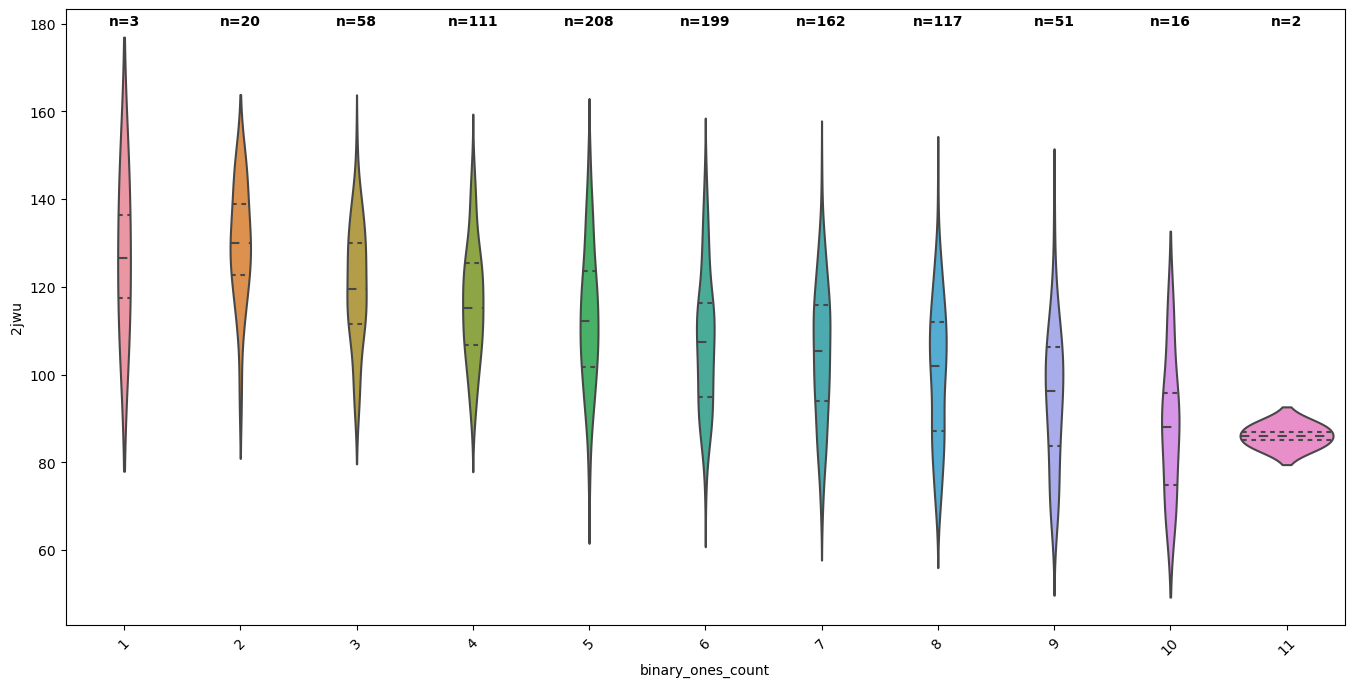

,count,mean,std,min,max
binary_ones_count,,,,,
1,3,127.128200,18.990562,108.4535,146.4196
2,20,129.655435,13.531476,95.7484,148.9664
3,58,120.394981,13.611883,91.7235,151.6678
4,111,116.183183,13.408692,88.2827,148.9117
5,208,112.911843,16.059830,72.5605,151.8709
6,199,107.567633,15.874624,71.7553,147.4426
7,162,104.722769,15.788947,69.1177,146.4068
8,117,100.332728,16.121947,68.4170,141.8441
9,51,94.701582,16.022967,64.2770,136.8597


In [38]:
create_violin_plots(avg_df, "binary_ones_count", avg_df.columns[3])

In [ ]:
nan_count = avg_df['column_name'].isna().sum()